# ==========================================================
# Rice Image Classification using Deep Learning
# Author: Muhammad Aulia Anhar
# ==========================================================



# 1. INTRODUCTION

Notebook ini disusun sebagai bagian dari penelitian klasifikasi beras berbasis citra
mendukung penulisan artikel ilmiah SINTA 3.
menggunakan pendekatan deep learning. Notebook ini bersifat journal-ready dan


Tujuan eksperimen:
1. Membangun baseline CNN untuk klasifikasi beras
2. Membandingkan performa CNN, ResNet, dan Vision Transformer
3. Mengevaluasi pengaruh data augmentation

A. Penanganan Data Imbalance (Penting!)
Data Anda sangat tidak seimbang (Kelas 0_NOR memiliki 18.000 gambar, sementara kelas lain hanya ~1.300).

Saran: Jangan hanya menggunakan Random Augmentation. Gunakan teknik Oversampling pada kelas minoritas atau Weighted Loss Function (misalnya Weighted Cross Entropy) dalam training loop. Dokumentasikan perbandingannya.

# 2. IMPORT LIBRARIES & DEVICE SETUP

In [2]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import time
import copy  # <--- Ini yang menyebabkan error tadi
import os
from sklearn.metrics import classification_report, confusion_matrix

# Setup Device (GPU jika tersedia)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Menggunakan perangkat: {device}")

Menggunakan perangkat: cuda


# 3. DESKRIPSI DATA
mendefinisikan di mana data berada dan melakukan inspeksi awal untuk melihat berapa banyak kelas yang

In [3]:
# Tentukan path sesuai struktur folder Anda
train_dir = "C:/Users/Anhar/Documents/#Semester 8/Project/Dataset/rice/train"
test_dir = "C:/Users/Anhar/Documents/#Semester 8/Project/Dataset/rice/test"


# Fungsi untuk mendeskripsikan isi dataset
def describe_dataset(directory):
    classes = os.listdir(directory)
    data_info = []
    total_images = 0

    for class_name in classes:
        path = os.path.join(directory, class_name)
        if os.path.isdir(path):
            n_images = len(os.listdir(path))
            data_info.append({"Kelas": class_name, "Jumlah Gambar": n_images})
            total_images += n_images

    df = pd.DataFrame(data_info)
    return df, total_images


# Eksekusi deskripsi data
train_stats, total_train = describe_dataset(train_dir)
test_stats, total_test = describe_dataset(test_dir)

print(f"Total gambar Training: {total_train}")
print("Detail per Kelas (Training):")
print(train_stats)

print(f"\nTotal gambar Testing: {total_test}")
print("Detail per Kelas (Testing):")
print(test_stats)

Total gambar Training: 27862
Detail per Kelas (Training):
   Kelas  Jumlah Gambar
0  0_NOR          18000
1  1_F&S           1336
2   2_SD           1350
3   3_MY           1350
4   4_AP           1350
5   5_BN           1341
6   6_UN           1335
7   7_IM           1800

Total gambar Testing: 3100
Detail per Kelas (Testing):
   Kelas  Jumlah Gambar
0  0_NOR           2000
1  1_F&S            150
2   2_SD            150
3   3_MY            150
4   4_AP            150
5   5_BN            150
6   6_UN            150
7   7_IM            200


# 4. explorasi data analysis (EDA)

visualisasikan ketimpangan data (imbalance) sebagai alasan menggunakan Skenario Optimasi nanti

### A. Visualisasi Distribusi Kelas

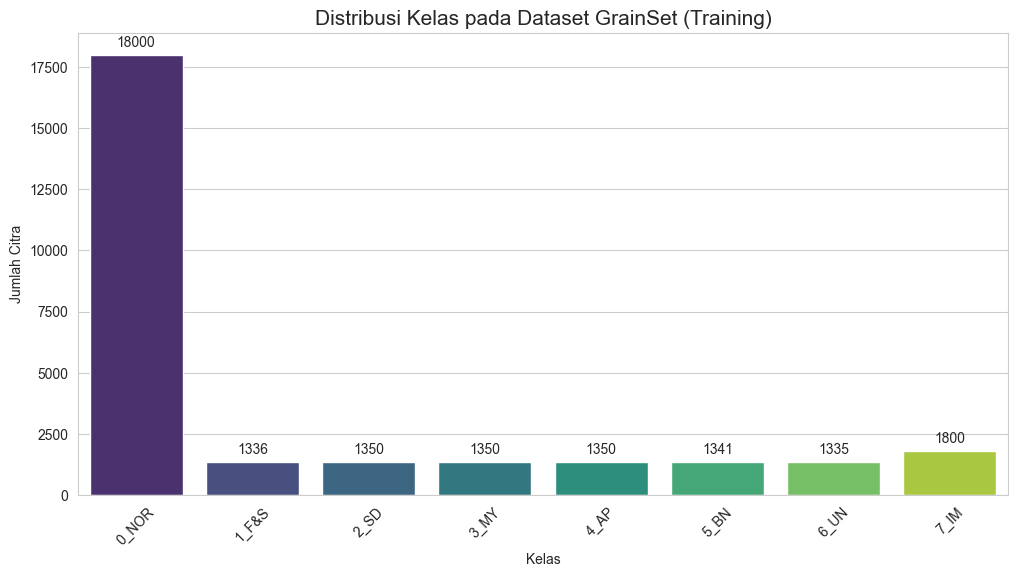

In [4]:
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
ax = sns.barplot(
    x="Kelas",
    y="Jumlah Gambar",
    data=train_stats,
    hue="Kelas",
    legend=False,
    palette="viridis",
)

plt.title("Distribusi Kelas pada Dataset GrainSet (Training)", fontsize=15)
plt.xticks(rotation=45)
plt.ylabel("Jumlah Citra")

import matplotlib.patches as mpatches

# Tambahkan label angka di atas bar
for p in ax.patches:
    if isinstance(p, mpatches.Rectangle):
        x = p.get_x() + p.get_width() / 2.0
        y = p.get_height()
        ax.annotate(
            format(y, ".0f"),
            (x, y),
            ha="center",
            va="center",
            xytext=(0, 9),
            textcoords="offset points",
        )
plt.show()

### Analisis Ketimpangan Data (Imbalance)
Data Anda sangat tidak seimbang:

Kelas Mayoritas: 0_NOR (18.000 gambar) — ini adalah 64% dari total data training.

Kelas Minoritas: Kelas 1 sampai 6 (hanya sekitar 1.300-an gambar per kelas).

Dampak: Ada perbedaan jumlah hampir 13 kali lipat antara kelas normal dan kelas cacat lainnya.

**Dataset yang digunakan terdiri dari citra beras yang dibagi menjadi 8 kelas berbeda. Berdasarkan inspeksi data dalam notebook:**

Total Data Training: 27.862 gambar.

Total Data Testing: 3.100 gambar.

Kelas Beras: Mencakup kelas 0_NOR, 1_F&S, 2_SD, 3_MY, 4_AP, 5_BN, 6_UN, dan 7_IM.

Terdapat indikasi ketimpangan data (data imbalance), di mana kelas 0_NOR memiliki jumlah gambar yang jauh lebih banyak (18.000 pada training) dibandingkan kelas lainnya.

### B. Visualisasi Sampel Gambar (Cek Kualitas)

contoh gambar dari setiap kategori

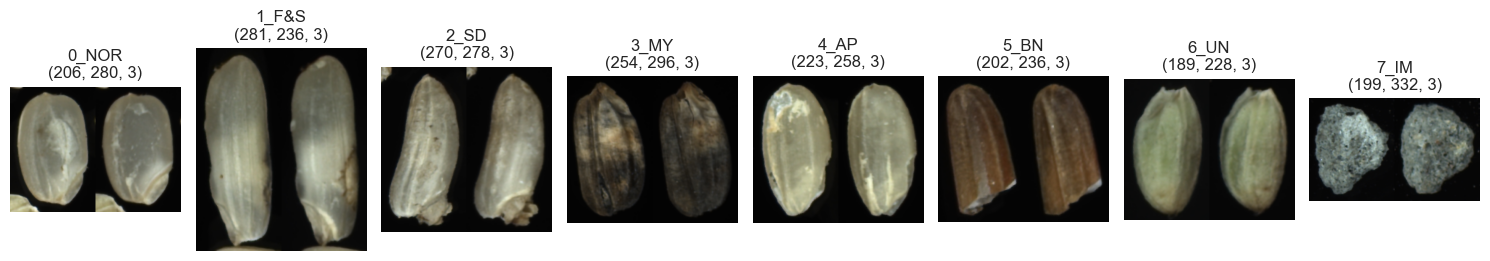

In [5]:
def show_samples(directory, num_samples=1):
    classes = os.listdir(directory)
    plt.figure(figsize=(15, 5))

    for i, class_name in enumerate(classes):
        class_path = os.path.join(directory, class_name)
        img_name = os.listdir(class_path)[0]
        img_path = os.path.join(class_path, img_name)

        img = plt.imread(img_path)
        plt.subplot(1, len(classes), i + 1)
        plt.imshow(img)
        plt.title(f"{class_name}\n{img.shape}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()


show_samples(train_dir)

In [6]:
# Wadah untuk menyimpan 9 kombinasi eksperimen
results_matrix = {
    "Skenario 1": {"MobileNetV3": None, "ResNet50": None, "ViT": None},
    "Skenario 2": {"MobileNetV3": None, "ResNet50": None, "ViT": None},
    "Skenario 3": {"MobileNetV3": None, "ResNet50": None, "ViT": None},
}


def save_to_matrix(scenario, model_name, history, report, cm, total_time):
    results_matrix[scenario][model_name] = {
        "history": history,
        "report": report,
        "cm": cm,
        "time": total_time,
    }
    print(f"✅ Data {model_name} pada {scenario} tersimpan.")

# 5. Modeling dengan Skenario Skenario C (Weighted Sampling)
Apa itu Skenario C (Weighted Sampling)?  
Pada Skenario 1 (Baseline), data training diambil secara acak tanpa memperhatikan jumlah tiap kelas. Akibatnya, kelas mayoritas (misalnya Normal) akan lebih sering muncul di batch, sementara kelas minoritas (misalnya Broken) jarang terlihat. Model pun cenderung “bermain aman” dengan menebak kelas mayoritas agar akurasi total terlihat tinggi.

Di Skenario C, saya menggunakan WeightedRandomSampler. Teknik ini bukan mengubah loss function, melainkan cara memilih data untuk masuk ke batch. Kelas minoritas akan lebih sering dipanggil, sehingga distribusi batch menjadi lebih seimbang.

**Analogi Sederhana**

- Skenario 1 (Baseline): Bayangkan ujian dengan 100 soal. 90 soal tentang “Penjumlahan” (kelas mayoritas) dan hanya 10 soal tentang “Integrasi” (kelas minoritas). Jika soal diambil acak, kemungkinan besar siswa akan mengerjakan soal penjumlahan terus-menerus, dan jarang sekali berlatih integrasi.

- Skenario C (Weighted Sampling): Kita ubah cara pengambilan soal. Walaupun soal integrasi hanya 10, kita atur agar soal integrasi muncul lebih sering di lembar ujian. Dengan begitu, siswa dipaksa berlatih kedua jenis soal secara seimbang.

Cara Kerja Teknis yang saya Lakukan:
- Hitung Distribusi:  
Cari jumlah sampel tiap kelas: 𝑁
𝑖
=jumlah sampel kelas 
𝑖 
- Hitung Bobot Sampling:  
Bobot tiap kelas dihitung sebagai kebalikan dari jumlah sampel: $$Weight_i = \frac{1}{ N_i}$$Injeksi ke 
- Model: Masukkan bobot tersebut ke dalam fungsi Loss di PyTorch.

- Injeksi ke Sampler:  
Bobot ini digunakan oleh WeightedRandomSampler untuk menentukan probabilitas pemilihan data.

Kelas dengan sampel sedikit → bobot besar → lebih sering dipilih.

Kelas dengan sampel banyak → bobot kecil → lebih jarang dipilih.


### A. Menghitung Bobot Kelas (Class Weights)
Jalankan ini untuk mendapatkan tensor bobot yang akan dimasukkan ke dalam CrossEntropyLoss.

Berikut ringkasan yang bisa langsung kamu masukkan ke jurnal (gaya formal ilmiah, ringkas tapi jelas):

---

 **Pemanfaatan CPU–GPU Hybrid pada Proses Pelatihan Model Deep Learning**

Pada penelitian ini, proses pelatihan model deep learning dilakukan dengan memanfaatkan arsitektur komputasi **hybrid antara CPU dan GPU** menggunakan framework PyTorch. Pendekatan ini bertujuan untuk meningkatkan efisiensi komputasi dan mempercepat waktu pelatihan model.

CPU (Central Processing Unit) digunakan untuk menangani proses **data pipeline**, meliputi pemuatan data (data loading), preprocessing, serta pembagian batch menggunakan `DataLoader`. Optimalisasi dilakukan dengan parameter `num_workers` untuk memungkinkan pemrosesan paralel, serta `pin_memory=True` untuk mempercepat transfer data dari memori CPU ke GPU.

Sementara itu, GPU (Graphics Processing Unit) digunakan untuk menjalankan proses utama dalam deep learning, yaitu **forward propagation, backward propagation, dan pembaruan bobot model**. Pemanfaatan GPU diaktifkan melalui mekanisme pemilihan perangkat menggunakan:

```python
torch.device("cuda" if torch.cuda.is_available() else "cpu")
```

dan pengiriman model serta data ke perangkat tersebut menggunakan `.to(device)`.

Selain itu, untuk mengatasi ketidakseimbangan data (imbalanced dataset), digunakan metode **class weighting** dengan menghitung bobot tiap kelas menggunakan fungsi `compute_class_weight`. Bobot tersebut kemudian diintegrasikan ke dalam fungsi loss `CrossEntropyLoss`, sehingga model memberikan perhatian lebih pada kelas minoritas.

Dengan pendekatan ini, CPU dan GPU bekerja secara paralel dalam sebuah pipeline, di mana CPU menyiapkan data untuk diproses, sementara GPU secara simultan melakukan pelatihan model. Strategi ini terbukti mampu mengurangi bottleneck pada proses pelatihan serta meningkatkan performa komputasi secara keseluruhan.

---


In [7]:
import torch
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
import numpy as np

# 1. Transformasi Data (Hanya Preprocessing Dasar)
# Augmentasi dihapus, hanya menyisakan Resize, ToTensor, dan Normalisasi
base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 2. Load Dataset
# Menggunakan base_transform yang sama untuk train dan test
train_dataset = datasets.ImageFolder(train_dir, transform=base_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=base_transform)

# 3. LOGIKA WEIGHTED SAMPLER UNTUK MENGATASI IMBALANCE
targets = np.array(train_dataset.targets)
class_sample_count = np.array(
    [len(np.where(targets == t)[0]) for t in np.unique(targets)]
)
weight = 1.0 / class_sample_count
samples_weight = torch.from_numpy(np.array([weight[t] for t in targets])).double()

sampler = WeightedRandomSampler(samples_weight, len(samples_weight))

# 4. DataLoader
# Tetap menggunakan sampler agar distribusi kelas tetap seimbang saat training
train_loader = DataLoader(
    train_dataset, 
    batch_size=32, 
    sampler=sampler, 
    num_workers=4, 
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=32, 
    shuffle=False, 
    num_workers=4, 
    pin_memory=True
)

Pembagian tugas Harwere
num_workers = 2

Artinya: 2 proses CPU paralel untuk load data

Fungsi:

- Membaca gambar / data dari disk
- Preprocessing (resize, transform, dll)

tujuanya:

Training jadi lebih cepat karena:
1. CPU menyiapkan data(background worker)

CPU menangani:

- DataLoader (loading data)
- num_workers (parallel loading)
- preprocessing (resize, transform)
- compute_class_weight (scikit-learn)

Jadi CPU menyiapkan dan mengirim data

2. GPU fokus training(main processor)

GPU menangani:

- model.to(device)
- forward pass (prediksi)
- backward pass (backpropagation)
- update weight (optimizer)

Jadi GPU melatih model (deep learning)


CPU:  Load batch ke-2   →   Load batch ke-3   →   Load batch ke-4

             ↓
             
GPU:      Train batch ke-1 → Train batch ke-2 → Train batch ke-3

Kode ini menghitung seberapa "langka" suatu kelas. Kelas yang jumlah gambarnya sedikit akan mendapat nilai bobot tinggi.

### M. Modeling dengan Weights

In [8]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)


def evaluate_and_save(scenario, model_name, model, test_loader, history, total_time):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Hitung Metrik Utama
    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    weighted_f1 = f1_score(all_labels, all_preds, average="weighted")

    # Classification Report & Confusion Matrix
    report = classification_report(
        all_labels, all_preds, target_names=train_dataset.classes, output_dict=True
    )
    cm = confusion_matrix(all_labels, all_preds)

    # Simpan ke Matrix Utama
    results_matrix[scenario][model_name] = {
        "Accuracy": acc,
        "Macro F1": macro_f1,
        "Weighted F1": weighted_f1,
        "Time": total_time,  # Dalam menit
        "Full Report": report,
        "Confusion Matrix": cm,
        "History": history,  # Berisi loss dan akurasi per epoch
    }

    print(f"✅ {model_name} ({scenario}) Berhasil Direkap.")
    print(f"Accuracy: {acc:.4f} | Macro F1: {macro_f1:.4f}")

**1. Eksperimen MobileNetV3 (Skenario B - Weighted)**

Perhatikan bagian criterion yang sekarang menerima parameter weight.

In [9]:
import torch.nn as nn
from torchvision import models


def get_mobilenet_v3(num_classes=8):
    # Menggunakan MobileNetV3-Large untuk keseimbangan akurasi dan kecepatan
    model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)

    # Menyesuaikan layer terakhir (classifier) dengan jumlah kelas GrainSet (8 kelas)
    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, num_classes)

    return model


# Inisialisasi model ke GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_mnv3 = get_mobilenet_v3(num_classes=8).to(device)

In [10]:
from torch.utils.data import random_split, DataLoader
import numpy as np

# 1. Bagi data training menjadi Train dan Validation (80:20)
# manual_seed(42) memastikan pembagian data selalu sama setiap kali dijalankan
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_subset, val_subset = random_split(
    train_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42)
)

# 2. Hitung ulang Sampler (Karena jumlah data berubah jadi 80%)
targets_train = [train_dataset.targets[i] for i in train_subset.indices]
class_sample_count = np.array(
    [len(np.where(np.array(targets_train) == t)[0]) for t in np.unique(targets_train)]
)
weight = 1.0 / class_sample_count
samples_weight = torch.from_numpy(np.array([weight[t] for t in targets_train])).double()
new_sampler = torch.utils.data.WeightedRandomSampler(
    samples_weight, len(samples_weight)
)

# 3. Definisi DataLoader Final
# Gunakan num_workers=0 jika Anda masih sering mendapat error "AttributeError" di Windows
train_loader = DataLoader(
    train_subset, batch_size=64, sampler=new_sampler, num_workers=4, pin_memory=True
)
val_loader = DataLoader(
    val_subset, batch_size=64, shuffle=False, num_workers=4, pin_memory=True
)

print(f"✅ Data Berhasil Dibagi!")
print(f"Training set: {len(train_subset)} gambar")
print(
    f"Validation set: {len(val_subset)} gambar (Ini yang akan jadi garis merah di grafik)"
)

✅ Data Berhasil Dibagi!
Training set: 22289 gambar
Validation set: 5573 gambar (Ini yang akan jadi garis merah di grafik)


In [11]:
import time
import torch
import torch.nn as nn
from tqdm import tqdm


def train_modeldef(
    model, train_loader, val_loader, criterion, optimizer, num_epochs=35
):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    scaler = torch.amp.GradScaler("cuda")

    for epoch in range(num_epochs):
        # --- PHASE TRAINING ---
        model.train()
        t_loss, t_correct, t_total = 0, 0, 0

        train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        for images, labels in train_loop:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            with torch.amp.autocast("cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            t_loss += loss.item()
            _, pred = outputs.max(1)
            t_total += labels.size(0)
            t_correct += pred.eq(labels).sum().item()
            train_loop.set_postfix(loss=loss.item(), acc=100.0 * t_correct / t_total)

        # --- PHASE VALIDATION ---
        model.eval()
        v_loss, v_correct, v_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                v_loss += loss.item()
                _, pred = outputs.max(1)
                v_total += labels.size(0)
                v_correct += pred.eq(labels).sum().item()

        # Simpan History
        history["train_loss"].append(t_loss / len(train_loader))
        history["train_acc"].append(100.0 * t_correct / t_total)
        history["val_loss"].append(v_loss / len(val_loader))
        history["val_acc"].append(100.0 * v_correct / v_total)

        print(
            f"Result Epoch {epoch+1}: Train Acc: {history['train_acc'][-1]:.2f}% | Val Acc: {history['val_acc'][-1]:.2f}%"
        )

    return model, history

In [12]:
import torch
import gc

gc.collect()
torch.cuda.empty_cache()

In [13]:
SCENARIO = "Skenario 2"
MODEL_NAME = "MobileNetV3"

# Inisialisasi
model_mnv3 = get_mobilenet_v3(num_classes=8).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_mnv3.parameters(), lr=0.0001)

# Training
start_time = time.time()
trained_model, history = train_modeldef(
    model_mnv3, train_loader, val_loader, criterion, optimizer, num_epochs=35
)
duration = (time.time() - start_time) / 60

# Simpan & Evaluasi
evaluate_and_save(SCENARIO, MODEL_NAME, trained_model, test_loader, history, duration)


# ... (kode training sebelumnya) ...

# --- SIMPAN MODEL ---
model_path_mnv3 = f"model_{MODEL_NAME}_{SCENARIO}.pth"
torch.save(trained_model.state_dict(), model_path_mnv3)
print(f"💾 Model disimpan sebagai: {model_path_mnv3}")

# --- BERSIHKAN MEMORI (PENTING!) ---
import gc

del trained_model, model_mnv3  # Hapus variabel model
torch.cuda.empty_cache()  # Kosongkan cache GPU
gc.collect()  # Jalankan sampah sistem
print(f"🧹 VRAM telah dibersihkan untuk model berikutnya.")

Epoch 1/35 [Train]: 100%|██████████| 349/349 [00:46<00:00,  7.49it/s, acc=93.4, loss=0.585]  


Result Epoch 1: Train Acc: 93.37% | Val Acc: 97.72%


Epoch 2/35 [Train]: 100%|██████████| 349/349 [00:44<00:00,  7.91it/s, acc=99.3, loss=0.00149] 


Result Epoch 2: Train Acc: 99.27% | Val Acc: 98.98%


Epoch 3/35 [Train]: 100%|██████████| 349/349 [00:44<00:00,  7.92it/s, acc=99.7, loss=0.00113] 


...

Result Epoch 33: Train Acc: 99.96% | Val Acc: 99.00%


Epoch 34/35 [Train]: 100%|██████████| 349/349 [00:44<00:00,  7.89it/s, acc=99.9, loss=0.00385] 


Result Epoch 34: Train Acc: 99.88% | Val Acc: 98.30%


Epoch 35/35 [Train]: 100%|██████████| 349/349 [00:44<00:00,  7.87it/s, acc=99.9, loss=1.4e-8]  


Result Epoch 35: Train Acc: 99.94% | Val Acc: 98.74%
✅ MobileNetV3 (Skenario 2) Berhasil Direkap.
Accuracy: 0.9542 | Macro F1: 0.9361
💾 Model disimpan sebagai: model_MobileNetV3_Skenario 2.pth
🧹 VRAM telah dibersihkan untuk model berikutnya.


**2. Eksperimen ResNet50 (Skenario B - Weighted)**

In [14]:
import torch.nn as nn
from torchvision import models


def get_resnet50(num_classes=8):
    # Memuat pre-trained ResNet50
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

    # Mengganti Fully Connected Layer terakhir
    # ResNet50 output aslinya adalah 2048 fiture
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    return model


# Inisialisasi model
model_resnet = get_resnet50(num_classes=8).to(device)

In [15]:
SCENARIO = "Skenario 2"
MODEL_NAME = "ResNet50"

# Inisialisasi
model_resnet = get_resnet50(num_classes=8).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_resnet.parameters(), lr=0.0001)

# Training
start_time = time.time()
trained_model, history = train_modeldef(
    model_resnet, train_loader, val_loader, criterion, optimizer, num_epochs=35
)
duration = (time.time() - start_time) / 60

# Simpan & Evaluasi
evaluate_and_save(SCENARIO, MODEL_NAME, trained_model, test_loader, history, duration)

# ... (kode training sebelumnya) ...

# --- SIMPAN MODEL ---
model_path_resnet = f"model_{MODEL_NAME}_{SCENARIO}.pth"
torch.save(trained_model, model_path_resnet)  # Simpan seluruh arsitektur
print(f"💾 Model disimpan sebagai: {model_path_resnet}")

# --- BERSIHKAN MEMORI ---
import gc

del trained_model, model_resnet
torch.cuda.empty_cache()
gc.collect()
print(f"🧹 VRAM telah dibersihkan.")

Epoch 1/35 [Train]: 100%|██████████| 349/349 [01:27<00:00,  4.00it/s, acc=94.3, loss=0.0168] 


Result Epoch 1: Train Acc: 94.27% | Val Acc: 98.40%


Epoch 2/35 [Train]: 100%|██████████| 349/349 [01:27<00:00,  3.99it/s, acc=99.4, loss=0.0333]  


Result Epoch 2: Train Acc: 99.37% | Val Acc: 98.33%


Epoch 3/35 [Train]: 100%|██████████| 349/349 [01:26<00:00,  4.04it/s, acc=99.6, loss=0.0106]  


...

Result Epoch 33: Train Acc: 99.85% | Val Acc: 98.74%


Epoch 34/35 [Train]: 100%|██████████| 349/349 [01:24<00:00,  4.11it/s, acc=100, loss=0.00135]  


Result Epoch 34: Train Acc: 99.96% | Val Acc: 98.83%


Epoch 35/35 [Train]: 100%|██████████| 349/349 [01:24<00:00,  4.12it/s, acc=100, loss=6.8e-6]  


Result Epoch 35: Train Acc: 100.00% | Val Acc: 98.98%
✅ ResNet50 (Skenario 2) Berhasil Direkap.
Accuracy: 0.9852 | Macro F1: 0.9731
💾 Model disimpan sebagai: model_ResNet50_Skenario 2.pth
🧹 VRAM telah dibersihkan.


**3. ViT (sekenario B - Weighted)**

Transformer seperti ViT, sangat disarankan menggunakan AdamW sebagai ganti Adam biasa karena lebih stabil dalam menangani bobot (weight decay), terutama saat menggunakan loss yang diberi bobot (weighted loss).

In [16]:
import timm
import torch.nn as nn


def get_vit_small(num_classes=8):
    # Menggunakan ViT-Small patch 16 dengan resolusi 224
    # 'vit_small_patch16_224' sangat cocok untuk RTX 3060 Anda
    model = timm.create_model("vit_small_patch16_224", pretrained=True)

    # Mengganti head classifier untuk 8 kelas beras
    model.head = nn.Linear(model.head.in_features, num_classes)

    return model


# Inisialisasi
model_vit = get_vit_small(num_classes=8).to(device)

In [17]:
# 1. Konfigurasi
SCENARIO = "Skenario 2"
MODEL_NAME = "ViT-Small"

# 2. Loss & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model_vit.parameters(), lr=5e-5, weight_decay=0.05)

print(f"🚀 Memulai Training {MODEL_NAME} pada {SCENARIO}...")
import time

start_time = time.time()

# 3. Proses Training (Hasil disimpan ke 'trained_model_vit')
trained_model_vit, history_vit = train_modeldef(
    model_vit, train_loader, val_loader, criterion, optimizer, num_epochs=35
)

duration_vit = (time.time() - start_time) / 60

# 4. Evaluasi dan Simpan ke Matrix
evaluate_and_save(
    SCENARIO, MODEL_NAME, trained_model_vit, test_loader, history_vit, duration_vit
)
print(f"✅ Training {MODEL_NAME} selesai dalam {duration_vit:.2f} menit.")

# --- 5. SIMPAN MODEL KE DISK ---
# Pastikan menggunakan nama variabel yang benar: trained_model_vit
model_path_vit = f"model_{MODEL_NAME}_{SCENARIO}.pth"
torch.save(trained_model_vit.state_dict(), model_path_vit)
print(f"💾 Model disimpan sebagai: {model_path_vit}")

# --- 6. BERSIHKAN MEMORI ---
import gc

# Hapus semua variabel yang memegang objek model
del trained_model_vit, model_vit
torch.cuda.empty_cache()
gc.collect()
print(f"🧹 VRAM telah dibersihkan. Siap untuk model berikutnya.")

🚀 Memulai Training ViT-Small pada Skenario 2...


Epoch 1/35 [Train]: 100%|██████████| 349/349 [01:13<00:00,  4.75it/s, acc=95.6, loss=0.0245] 


Result Epoch 1: Train Acc: 95.59% | Val Acc: 97.69%


Epoch 2/35 [Train]: 100%|██████████| 349/349 [01:12<00:00,  4.82it/s, acc=99.3, loss=0.000874]


Result Epoch 2: Train Acc: 99.34% | Val Acc: 98.67%


...

Result Epoch 33: Train Acc: 99.88% | Val Acc: 97.20%


Epoch 34/35 [Train]: 100%|██████████| 349/349 [01:11<00:00,  4.86it/s, acc=99.5, loss=6.74e-5] 


Result Epoch 34: Train Acc: 99.48% | Val Acc: 98.94%


Epoch 35/35 [Train]: 100%|██████████| 349/349 [01:11<00:00,  4.86it/s, acc=100, loss=3.01e-5] 


Result Epoch 35: Train Acc: 99.99% | Val Acc: 98.85%
✅ ViT-Small (Skenario 2) Berhasil Direkap.
Accuracy: 0.9813 | Macro F1: 0.9707
✅ Training ViT-Small selesai dalam 56.45 menit.
💾 Model disimpan sebagai: model_ViT-Small_Skenario 2.pth
🧹 VRAM telah dibersihkan. Siap untuk model berikutnya.


### C. Evaluasi Skenario 2
Untuk melihat perbaikan pada Macro F1-Score.

In [18]:
import pandas as pd


def generate_summary_table(results_dict):
    rows = []
    for scenario, models in results_dict.items():
        for model_name, metrics in models.items():
            if metrics is not None:
                rows.append(
                    {
                        "Skenario": scenario,
                        "Model": model_name,
                        "Accuracy (%)": f"{metrics['Accuracy']*100:.2f}",
                        "Macro F1": round(metrics["Macro F1"], 4),
                        "Weighted F1": round(metrics["Weighted F1"], 4),
                        "Time (Min)": round(metrics["Time"], 2),
                    }
                )

    df = pd.DataFrame(rows)
    return df


# Eksekusi
df_hasil = generate_summary_table(results_matrix)
print("=== Rekapitulasi Hasil Eksperimen ===")
display(df_hasil)

=== Rekapitulasi Hasil Eksperimen ===


,Skenario,Model,Accuracy (%),Macro F1,Weighted F1,Time (Min)
0,Skenario 2,MobileNetV3,95.42,0.9361,0.9569,35.70
1,Skenario 2,ResNet50,98.52,0.9731,0.9853,118.36
2,Skenario 2,ViT-Small,98.13,0.9707,0.9818,56.45


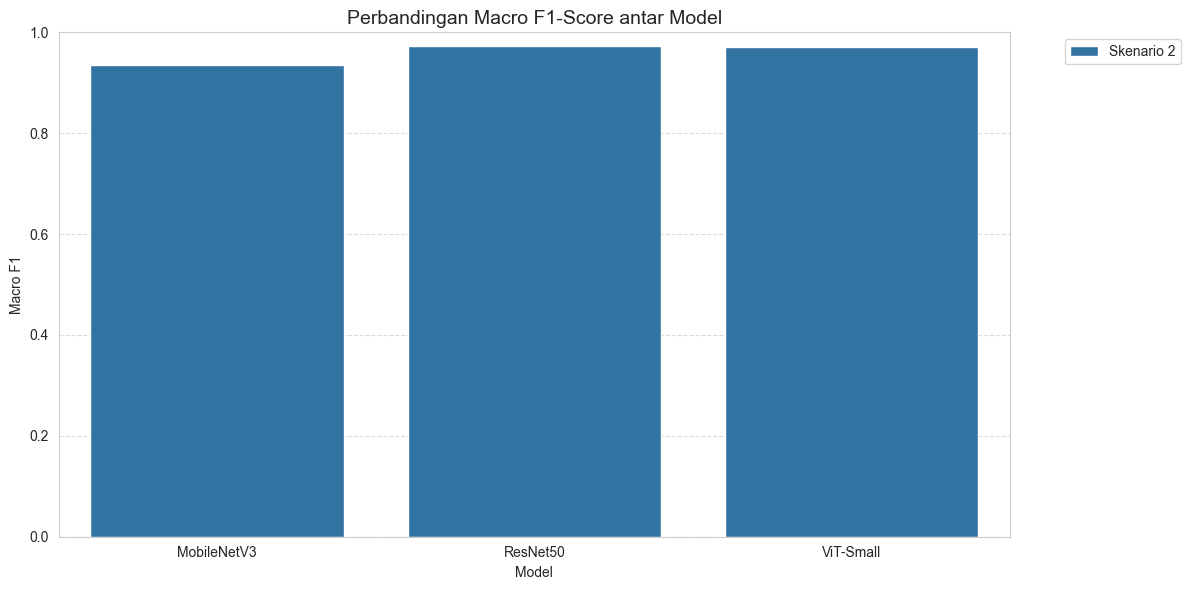

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns


def plot_comparison(df):
    plt.figure(figsize=(12, 6))

    # Plot Macro F1 (Metrik paling jujur untuk data imbalance)
    sns.barplot(data=df, x="Model", y="Macro F1", hue="Skenario")

    plt.title("Perbandingan Macro F1-Score antar Model", fontsize=14)
    plt.ylim(0, 1.0)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()


plot_comparison(df_hasil)

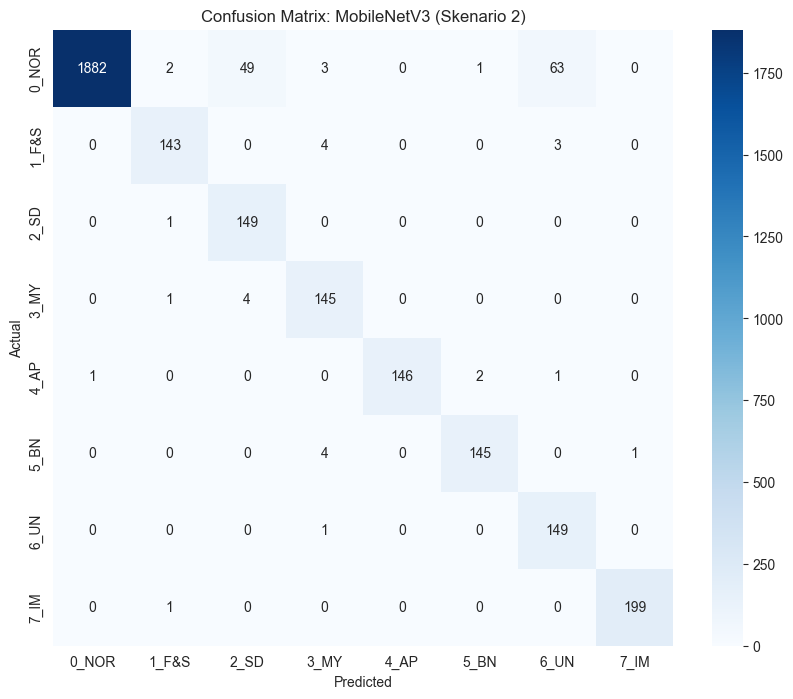


=== Detail Report per Kelas: MobileNetV3 ===


,precision,recall,f1-score,support
0_NOR,0.999469,0.941000,0.969354,2000.000000
1_F&S,0.966216,0.953333,0.959732,150.000000
2_SD,0.737624,0.993333,0.846591,150.000000
3_MY,0.923567,0.966667,0.944625,150.000000
4_AP,1.000000,0.973333,0.986486,150.000000
5_BN,0.979730,0.966667,0.973154,150.000000
6_UN,0.689815,0.993333,0.814208,150.000000
7_IM,0.995000,0.995000,0.995000,200.000000
accuracy,0.954194,0.954194,0.954194,0.954194
macro avg,0.911428,0.972833,0.936144,3100.000000


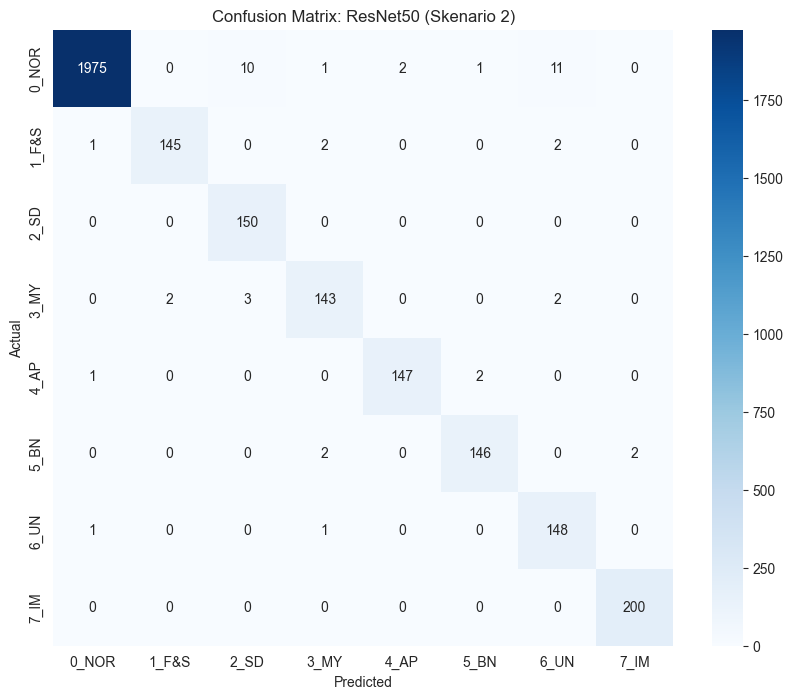


=== Detail Report per Kelas: ResNet50 ===


,precision,recall,f1-score,support
0_NOR,0.998483,0.987500,0.992961,2000.000000
1_F&S,0.986395,0.966667,0.976431,150.000000
2_SD,0.920245,1.000000,0.958466,150.000000
3_MY,0.959732,0.953333,0.956522,150.000000
4_AP,0.986577,0.980000,0.983278,150.000000
5_BN,0.979866,0.973333,0.976589,150.000000
6_UN,0.907975,0.986667,0.945687,150.000000
7_IM,0.990099,1.000000,0.995025,200.000000
accuracy,0.985161,0.985161,0.985161,0.985161
macro avg,0.966172,0.980938,0.973120,3100.000000


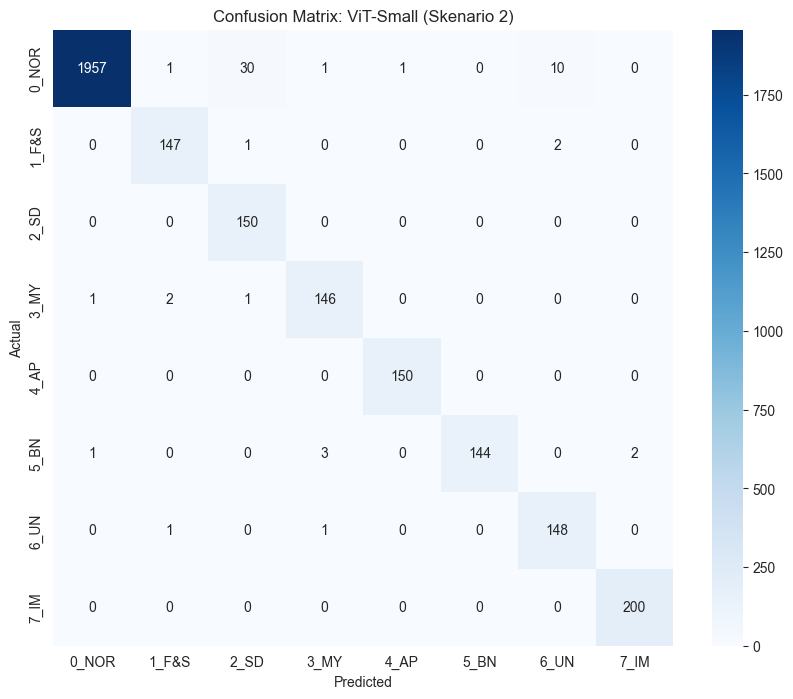


=== Detail Report per Kelas: ViT-Small ===


,precision,recall,f1-score,support
0_NOR,0.998979,0.978500,0.988633,2000.00000
1_F&S,0.973510,0.980000,0.976744,150.00000
2_SD,0.824176,1.000000,0.903614,150.00000
3_MY,0.966887,0.973333,0.970100,150.00000
4_AP,0.993377,1.000000,0.996678,150.00000
5_BN,1.000000,0.960000,0.979592,150.00000
6_UN,0.925000,0.986667,0.954839,150.00000
7_IM,0.990099,1.000000,0.995025,200.00000
accuracy,0.981290,0.981290,0.981290,0.98129
macro avg,0.959004,0.984813,0.970653,3100.00000


In [20]:
def plot_detail_model(scenario, model_name):
    data = results_matrix[scenario][model_name]
    if data is None:
        print("Data tidak ditemukan!")
        return

    # 1. Plot Confusion Matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        data["Confusion Matrix"],
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=train_dataset.classes,
        yticklabels=train_dataset.classes,
    )
    plt.title(f"Confusion Matrix: {model_name} ({scenario})")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.show()

    # 2. Print Classification Report (Precision, Recall, F1 per kelas)
    print(f"\n=== Detail Report per Kelas: {model_name} ===")
    report_df = pd.DataFrame(data["Full Report"]).transpose()
    display(report_df)


# Contoh penggunaan:
plot_detail_model("Skenario 2", "MobileNetV3")
plot_detail_model("Skenario 2", "ResNet50")
plot_detail_model("Skenario 2", "ViT-Small")

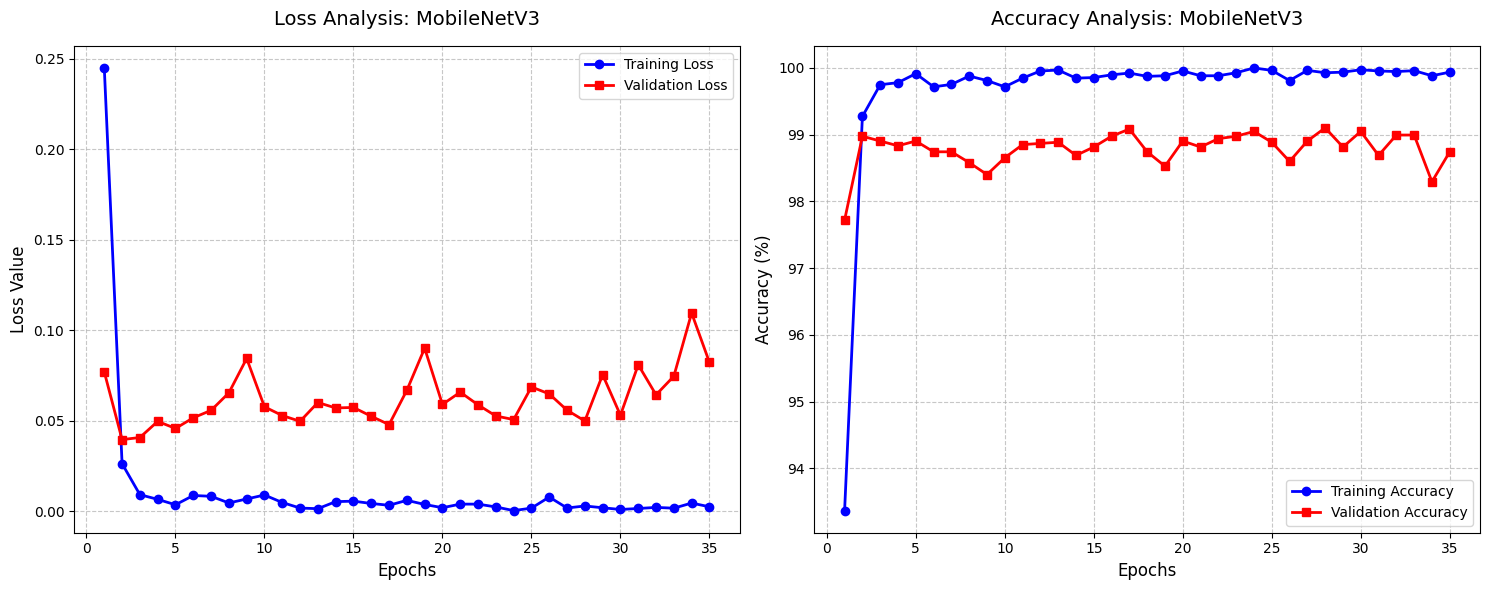

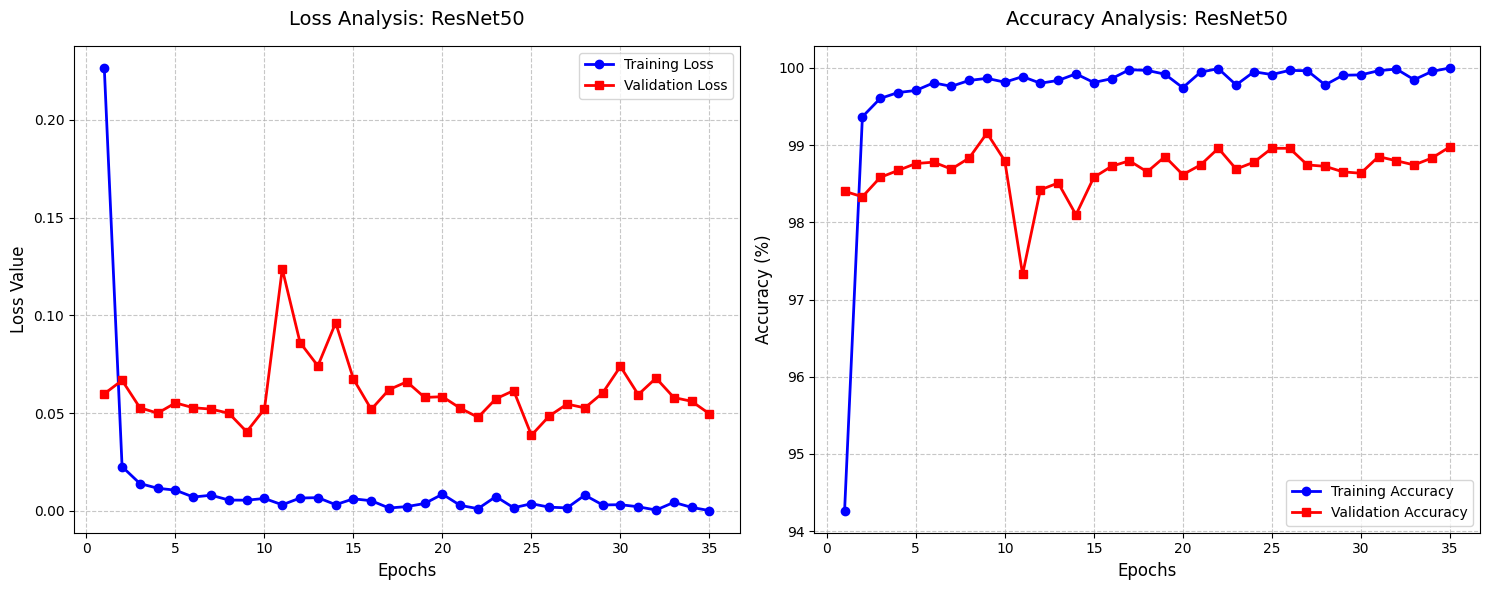

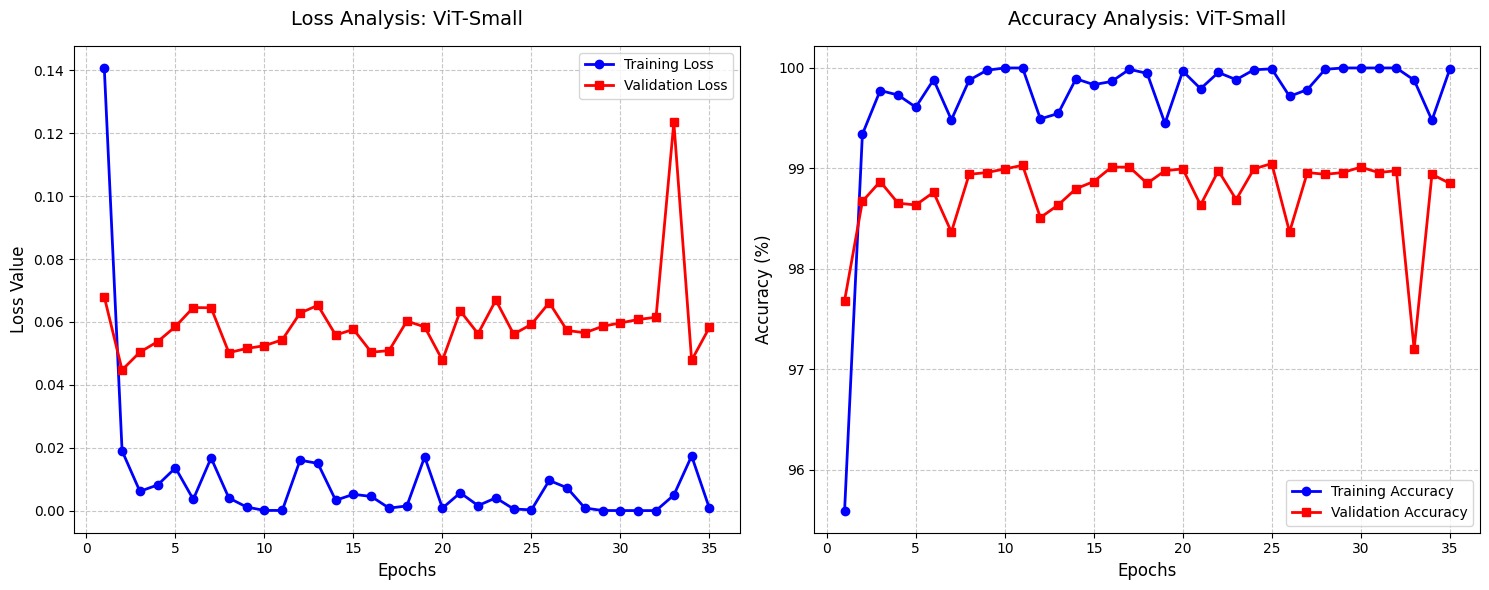

In [21]:
import matplotlib.pyplot as plt


def plot_final_results(scenario, model_name):
    # 1. Ambil data dari wadah
    data_model = results_matrix[scenario][model_name]
    history = data_model.get("History") or data_model.get("history")

    if history is None:
        print(
            "❌ Data history tidak ditemukan. Pastikan Anda sudah menjalankan training ulang dengan validasi."
        )
        return

    epochs = range(1, len(history["train_loss"]) + 1)

    # Set style standar jurnal (Putih, Bersih, High Contrast)
    plt.style.use("default")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # --- GRAFIK 1: TRAINING VS VALIDATION LOSS ---
    ax1.plot(
        epochs,
        history["train_loss"],
        "b-o",
        label="Training Loss",
        linewidth=2,
        markersize=6,
    )
    ax1.plot(
        epochs,
        history["val_loss"],
        "r-s",
        label="Validation Loss",
        linewidth=2,
        markersize=6,
    )

    ax1.set_title(f"Loss Analysis: {model_name}", fontsize=14, pad=15)
    ax1.set_xlabel("Epochs", fontsize=12)
    ax1.set_ylabel("Loss Value", fontsize=12)
    ax1.legend(loc="upper right")
    ax1.grid(True, linestyle="--", alpha=0.7)

    # --- GRAFIK 2: TRAINING VS VALIDATION ACCURACY ---
    ax2.plot(
        epochs,
        history["train_acc"],
        "b-o",
        label="Training Accuracy",
        linewidth=2,
        markersize=6,
    )
    ax2.plot(
        epochs,
        history["val_acc"],
        "r-s",
        label="Validation Accuracy",
        linewidth=2,
        markersize=6,
    )

    ax2.set_title(f"Accuracy Analysis: {model_name}", fontsize=14, pad=15)
    ax2.set_xlabel("Epochs", fontsize=12)
    ax2.set_ylabel("Accuracy (%)", fontsize=12)
    ax2.legend(loc="lower right")
    ax2.grid(True, linestyle="--", alpha=0.7)

    plt.tight_layout()

    # Simpan untuk kebutuhan Paper SINTA 3
    # file_name = f"Final_Graph_{model_name}_{scenario}.png"
    # plt.savefig(file_name, dpi=300, bbox_inches='tight')

    plt.show()
    # print(f"✅ Grafik telah disimpan sebagai: {file_name}")


# Cara Menjalankan:
plot_final_results("Skenario 2", "MobileNetV3")
plot_final_results("Skenario 2", "ResNet50")
plot_final_results("Skenario 2", "ViT-Small")

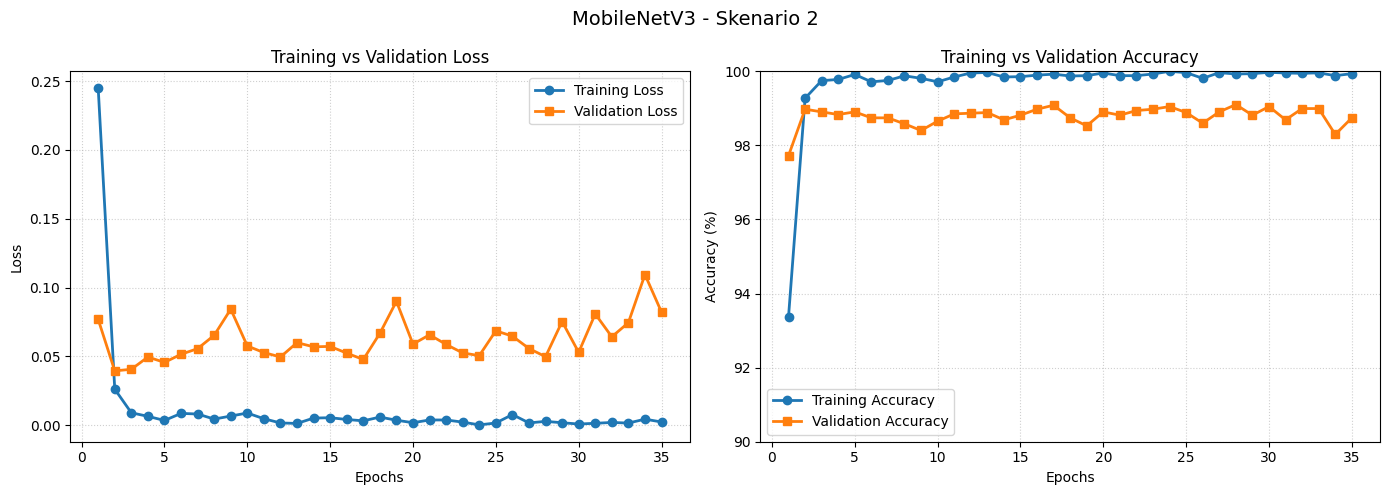

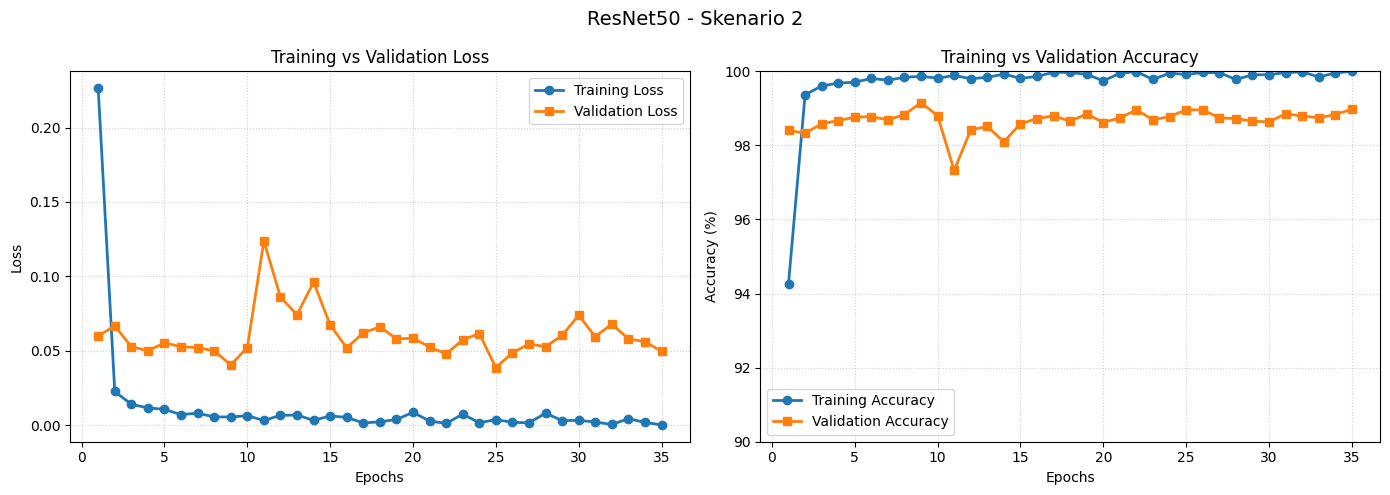

⚠️ ViT tidak punya data


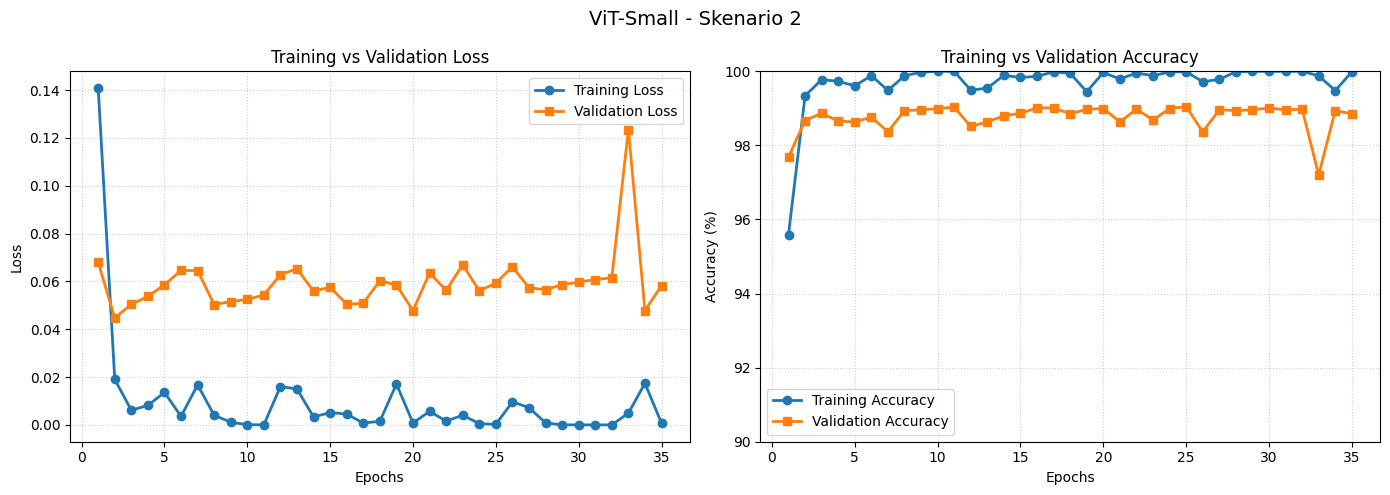

In [22]:
import matplotlib.pyplot as plt


def plot_loss_dan_akurasi(scenario_name):
    # Cek apakah skenario ada
    if scenario_name not in results_matrix or not results_matrix[scenario_name]:
        print(f"⚠️ Data untuk {scenario_name} tidak ditemukan.")
        return

    for model_name, data in results_matrix[scenario_name].items():

        # Ambil history (handle 'History' dan 'history')
        if data is None:
            print(f"⚠️ {model_name} tidak punya data")
            continue

        history = data.get("history") or data.get("History")

        if history is None:
            print(f"⚠️ {model_name} belum ada history training")
            continue

        epochs = range(1, len(history["train_acc"]) + 1)

        # === PLOT ===
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # ===================== LOSS =====================
        axes[0].plot(
            epochs,
            history["train_loss"],
            marker="o",
            linewidth=2,
            label="Training Loss",
        )
        axes[0].plot(
            epochs,
            history["val_loss"],
            marker="s",
            linewidth=2,
            label="Validation Loss",
        )

        axes[0].set_title("Training vs Validation Loss")
        axes[0].set_xlabel("Epochs")
        axes[0].set_ylabel("Loss")
        axes[0].legend()
        axes[0].grid(True, linestyle=":", alpha=0.6)

        # ===================== ACCURACY =====================
        axes[1].plot(
            epochs,
            history["train_acc"],
            marker="o",
            linewidth=2,
            label="Training Accuracy",
        )
        axes[1].plot(
            epochs,
            history["val_acc"],
            marker="s",
            linewidth=2,
            label="Validation Accuracy",
        )

        axes[1].set_title("Training vs Validation Accuracy")
        axes[1].set_xlabel("Epochs")
        axes[1].set_ylabel("Accuracy (%)")
        axes[1].set_ylim(90, 100)  # karena kamu pakai persen
        axes[1].legend()
        axes[1].grid(True, linestyle=":", alpha=0.6)

        # Judul utama
        fig.suptitle(f"{model_name} - {scenario_name}", fontsize=14)

        plt.tight_layout()

        # Simpan (penting untuk jurnal)
        # file_name = f"Final_Graph_{model_name}_{scenario_name}.png"
        # plt.savefig(file_name, dpi=300, bbox_inches='tight')

        plt.show()

        # print(f"✅ Grafik disimpan: {file_name}")


# Jalankan
plot_loss_dan_akurasi("Skenario 2")

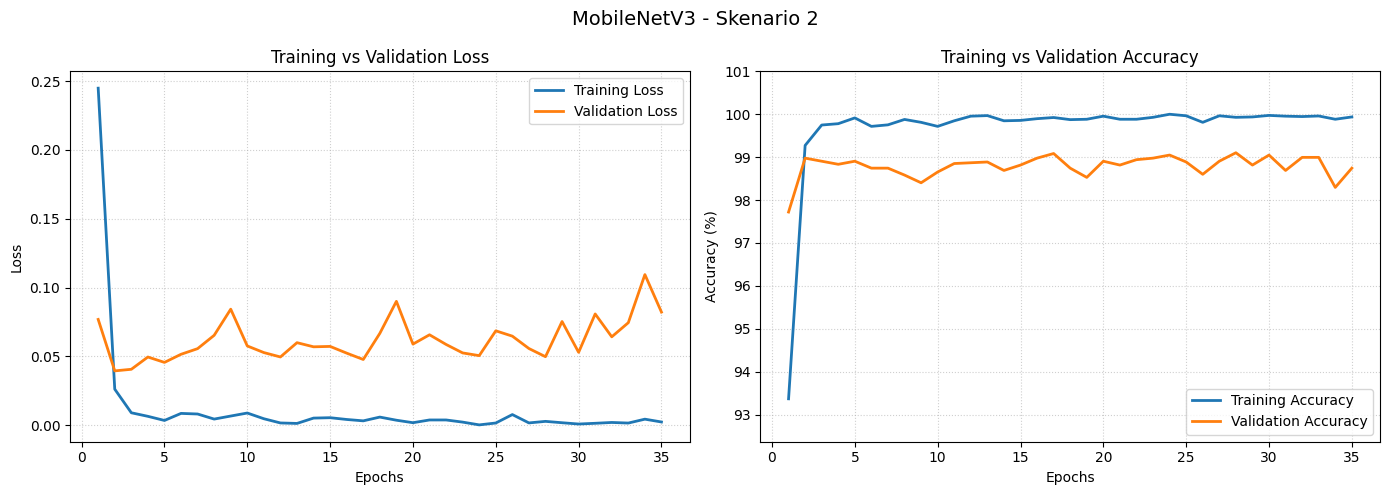

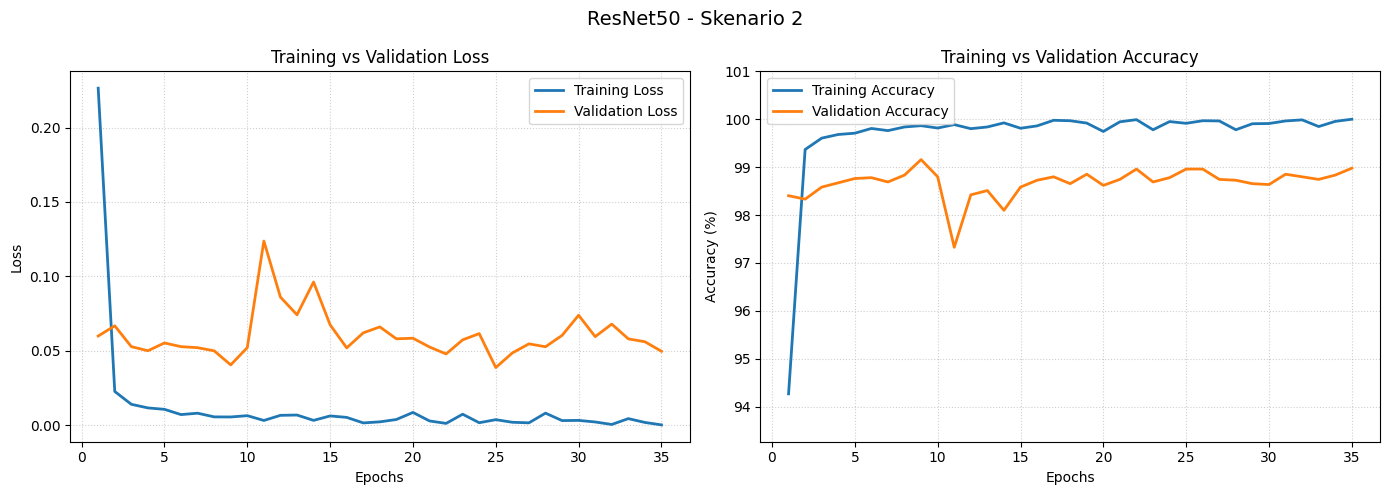

⚠️ ViT tidak punya data


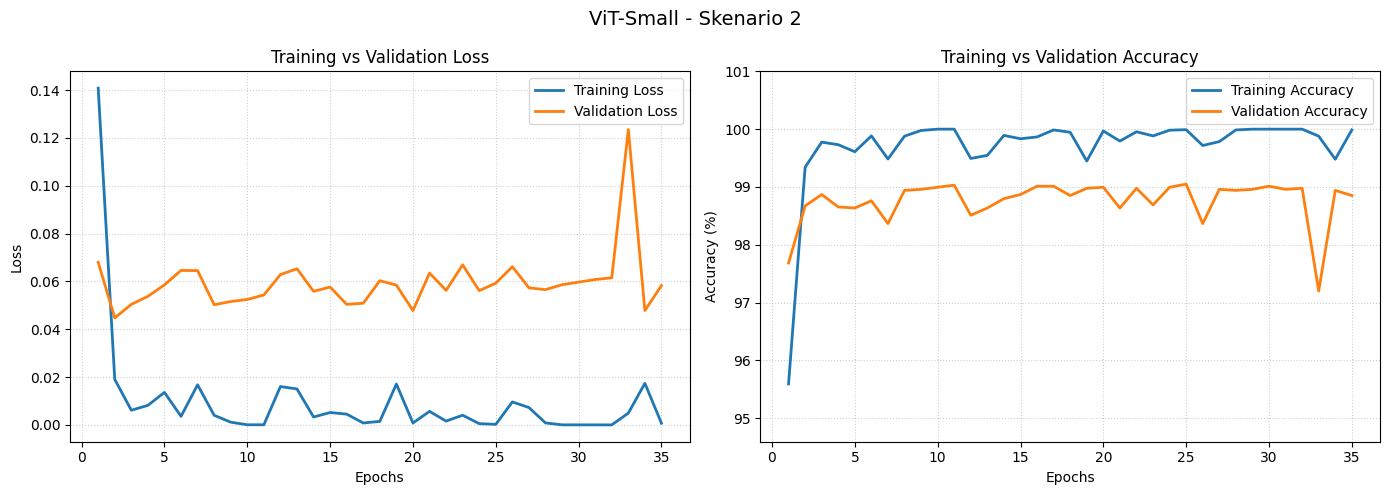

In [23]:
import matplotlib.pyplot as plt


def plot_loss_dan_akurasi(scenario_name):
    # Cek apakah skenario ada
    if scenario_name not in results_matrix or not results_matrix[scenario_name]:
        print(f"⚠️ Data untuk {scenario_name} tidak ditemukan.")
        return

    for model_name, data in results_matrix[scenario_name].items():

        # Ambil history (handle 'history' / 'History')
        if data is None:
            print(f"⚠️ {model_name} tidak punya data")
            continue

        history = data.get("history") or data.get("History")
        if history is None:
            print(f"⚠️ {model_name} belum ada history training")
            continue

        epochs = range(1, len(history["train_acc"]) + 1)

        # === PLOT ===
        plt.style.use("default")
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # ===================== LOSS =====================
        axes[0].plot(
            epochs,
            history["train_loss"],
            linestyle="-",
            linewidth=2,
            label="Training Loss",
        )
        axes[0].plot(
            epochs,
            history["val_loss"],
            linestyle="-",
            linewidth=2,
            label="Validation Loss",
        )

        axes[0].set_title("Training vs Validation Loss")
        axes[0].set_xlabel("Epochs")
        axes[0].set_ylabel("Loss")
        axes[0].legend()
        axes[0].grid(True, linestyle=":", alpha=0.6)

        # ===================== ACCURACY =====================
        axes[1].plot(
            epochs,
            history["train_acc"],
            linestyle="-",
            linewidth=2,
            label="Training Accuracy",
        )
        axes[1].plot(
            epochs,
            history["val_acc"],
            linestyle="-",
            linewidth=2,
            label="Validation Accuracy",
        )

        axes[1].set_title("Training vs Validation Accuracy")
        axes[1].set_xlabel("Epochs")
        axes[1].set_ylabel("Accuracy (%)")

        # 🔥 Auto zoom biar tidak “flat”
        min_acc = min(min(history["train_acc"]), min(history["val_acc"]))
        max_acc = max(max(history["train_acc"]), max(history["val_acc"]))
        axes[1].set_ylim(min_acc - 1, max_acc + 1)

        axes[1].legend()
        axes[1].grid(True, linestyle=":", alpha=0.6)

        # Judul utama
        fig.suptitle(f"{model_name} - {scenario_name}", fontsize=14)

        plt.tight_layout()

        # Simpan gambar (untuk jurnal)
        # file_name = f"Final_Graph_{model_name}_{scenario_name}.png"
        # plt.savefig(file_name, dpi=300, bbox_inches='tight')

        plt.show()

        # print(f"✅ Grafik disimpan: {file_name}")


# Jalankan
plot_loss_dan_akurasi("Skenario 2")

# 3. Struktur Tabel untuk Paper (Pandas)
Setelah semua eksperimen selesai, Anda bisa mengubah results_matrix menjadi DataFrame agar bisa langsung di-copy ke tabel Microsoft Word untuk artikel SINTA 3 Anda.

In [24]:
import pandas as pd


def summary_to_table():
    summary_list = []
    for scenario, models in results_matrix.items():
        for model_name, data in models.items():
            if data is not None:
                summary_list.append(
                    {
                        "Scenario": scenario,
                        "Model": model_name,
                        "Accuracy": f"{data['Accuracy']*100:.2f}%",
                        "Macro F1": f"{data['Macro F1']:.4f}",
                        "Weighted F1": f"{data['Weighted F1']:.4f}",
                        "Time (Min)": f"{data['Time']:.2f}",
                    }
                )
    return pd.DataFrame(summary_list)


# Panggil ini setelah semua training selesai
df_hasil = summary_to_table()
print(df_hasil)

     Scenario        Model Accuracy Macro F1 Weighted F1 Time (Min)
0  Skenario 2  MobileNetV3   95.42%   0.9361      0.9569      35.70
1  Skenario 2     ResNet50   98.52%   0.9731      0.9853     118.36
2  Skenario 2    ViT-Small   98.13%   0.9707      0.9818      56.45


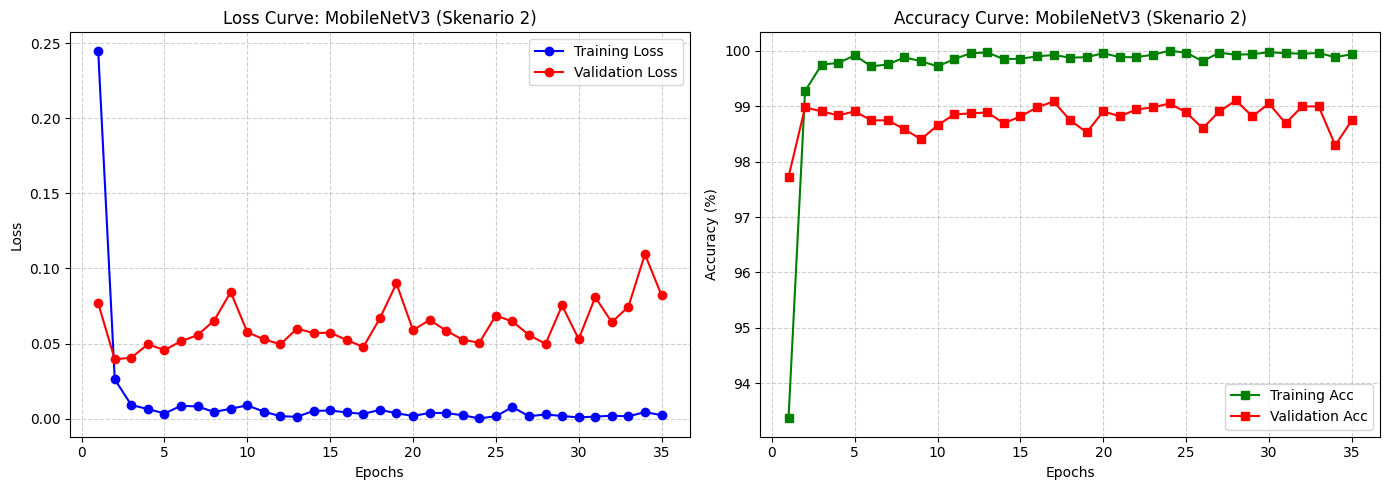

In [25]:
import matplotlib.pyplot as plt


def plot_training_history(scenario, model_name):
    # 1. Ambil data dari wadah results_matrix
    data_model = results_matrix[scenario][model_name]

    # 2. Cek apakah kuncinya 'History' atau 'history' agar tidak error lagi
    history = data_model.get("History") or data_model.get("history")

    if history is None:
        print(f"❌ Data history untuk {model_name} tidak ditemukan!")
        return

    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(14, 5))

    # --- 1. Plot Loss Curve ---
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], "b-o", label="Training Loss")
    if "val_loss" in history:
        plt.plot(epochs, history["val_loss"], "r-o", label="Validation Loss")

    plt.title(f"Loss Curve: {model_name} ({scenario})", fontsize=12)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)

    # --- 2. Plot Accuracy Curve ---
    plt.subplot(1, 2, 2)
    plt.plot(
        epochs, history["train_acc"], "g-s", label="Training Acc"
    )  # Hijau untuk Training
    if "val_acc" in history:
        plt.plot(
            epochs, history["val_acc"], "r-s", label="Validation Acc"
        )  # Merah untuk Val

    plt.title(f"Accuracy Curve: {model_name} ({scenario})", fontsize=12)
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy (%)")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()


# Jalankan ulang pemanggilan:
plot_training_history("Skenario 2", "MobileNetV3")